In [46]:
import pandas as pd
pd.set_option("display.max_columns", 24)

# Importing the data

In [47]:
df_amazon = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-6/data/Amazon Sale Report.csv")
df_amazon.set_index("index", inplace=True)
df_amazon.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


# Preprocessing

In [48]:
df_amazon.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

<b><p>
First, we will handle the null values in the Courier Status.
</b>

In [49]:
# df_amazon[ (df_amazon["Courier Status"].isna()) & ~(df_amazon["Amount"].isna()) & (df_amazon["Status"]=="Cancelled") ]
df_amazon[ (df_amazon["Status"]=='Shipped - Delivered to Buyer') ]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Shipped,1,INR,399.0,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
12,405-5513694-8146768,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-XS,kurta,XS,B081XCMYXJ,Shipped,1,INR,399.0,Amravati.,MAHARASHTRA,444606.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
14,408-1298370-1920302,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,J0351-SET-L,Set,L,B09CSSQY4F,Shipped,1,INR,771.0,MUMBAI,MAHARASHTRA,400053.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
15,403-4965581-9520319,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,PJNE3368,PJNE3368-KR-6XL,kurta,6XL,B09PY99SVJ,Shipped,1,INR,544.0,GUNTAKAL,ANDHRA PRADESH,515801.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128872,405-4724097-1016369,06-01-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0243,J0243-DR-S,Ethnic Dress,S,B092648LBY,Shipped,1,INR,999.0,ALLUR,ANDHRA PRADESH,524315.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
128873,405-4724097-1016369,06-01-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0079,J0079-SKD-S,Set,S,B08XNG67ZL,Shipped,1,INR,1523.0,ALLUR,ANDHRA PRADESH,524315.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
128874,405-4724097-1016369,06-01-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0009,J0009-SKD-S,Set,S,B0894X8979,Shipped,1,INR,854.0,ALLUR,ANDHRA PRADESH,524315.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


In [50]:
df_amazon["Status"].unique().tolist()

['Cancelled',
 'Shipped - Delivered to Buyer',
 'Shipped',
 'Shipped - Returned to Seller',
 'Shipped - Rejected by Buyer',
 'Shipped - Lost in Transit',
 'Shipped - Out for Delivery',
 'Shipped - Returning to Seller',
 'Shipped - Picked Up',
 'Pending',
 'Pending - Waiting for Pick Up',
 'Shipped - Damaged',
 'Shipping']

<p>
To account for the analysis of sales we will only take the orders that have ben <b>successfully shipped to buyer</b>, <b>out for dilevery</b>, <b>picked up</b>. 


In [51]:
df_amazon_sales_completed = df_amazon[ (df_amazon["Status"]=='Shipped - Delivered to Buyer') | 
                                        (df_amazon["Status"]=='Shipped') |
                                        (df_amazon["Status"]=='Shipped - Out for Delivery') | 
                                        (df_amazon["Status"]=='Shipped - Picked Up')]
df_amazon_sales_completed.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.0,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.0,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


I will add the date, time and year columns by splitting from the date column.

In [52]:
df_amazon_sales_completed[["Month", "Day", "Year"]] = df_amazon_sales_completed["Date"].str.split("-", expand=True)
df_amazon_sales_completed.drop(["Date"], axis="columns", inplace=True)

Dropping out the unnecessary columns

In [53]:
df_amazon_sales_completed.drop(["promotion-ids", "Unnamed: 22"], axis="columns", inplace=True)

Filling NULL values in ship-country column. 

In [54]:
df_amazon_sales_completed["ship-country"].unique().tolist()

['IN', nan]

In [55]:
df_amazon_sales_completed["ship-country"] = df_amazon_sales_completed["ship-country"].fillna("IN")

In [56]:
df_amazon_sales_completed.drop(["ship-postal-code"], axis="columns", inplace=True)

In [57]:
df_amazon_sales_completed.dropna(subset=["ship-city", "ship-state"], inplace=True)

In [58]:
df_amazon_sales_completed.drop(["currency"], axis="columns", inplace=True)

In [59]:
df_amazon_sales_completed.dropna(subset=["Amount"], inplace=True)

In [60]:
df_amazon_sales_completed.drop(["fulfilled-by", "B2B"], axis="columns", inplace=True)

Rectitfying the value for the states for the 'ship-state' column.

In [61]:
df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "New Delhi" if x == "Delhi" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Puducherry" if x == "Pondicherry" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Punjab" if x == "Pb" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Punjab" if x == "Punjab/Mohali/Zirakpur" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Nagaland" if x == "Nl" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Rajasthan" if x == "Rj" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Rajasthan" if x == "Rajsthan" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Arunachal Pradesh" if x == "Ar" else x
)

In [62]:
df_amazon_sales_completed["ship-state"].unique().tolist()

['KARNATAKA',
 'MAHARASHTRA',
 'TAMIL NADU',
 'UTTAR PRADESH',
 'CHANDIGARH',
 'TELANGANA',
 'ANDHRA PRADESH',
 'RAJASTHAN',
 'DELHI',
 'HARYANA',
 'ASSAM',
 'JHARKHAND',
 'CHHATTISGARH',
 'ODISHA',
 'KERALA',
 'MADHYA PRADESH',
 'WEST BENGAL',
 'NAGALAND',
 'Gujarat',
 'UTTARAKHAND',
 'BIHAR',
 'JAMMU & KASHMIR',
 'PUNJAB',
 'HIMACHAL PRADESH',
 'ARUNACHAL PRADESH',
 'MANIPUR',
 'Goa',
 'MEGHALAYA',
 'PUDUCHERRY',
 'GOA',
 'TRIPURA',
 'LADAKH',
 'DADRA AND NAGAR',
 'SIKKIM',
 'New Delhi',
 'ANDAMAN & NICOBAR ',
 'Punjab',
 'Rajshthan',
 'Manipur',
 'rajasthan',
 'Odisha',
 'NL',
 'Bihar',
 'MIZORAM',
 'punjab',
 'Rajasthan',
 'Puducherry',
 'delhi',
 'RJ',
 'Chandigarh',
 'orissa',
 'LAKSHADWEEP',
 'goa',
 'PB',
 'Arunachal Pradesh',
 'AR',
 'Sikkim',
 'Arunachal pradesh',
 'Nagaland',
 'bihar',
 'Mizoram',
 'rajsthan',
 'Orissa']

In [63]:
df_amazon_sales_completed.isnull().sum()

Order ID              0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-country          0
Month                 0
Day                   0
Year                  0
dtype: int64

Saving the file

In [64]:
df_amazon_sales_completed.to_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-6/data/amazon_final.csv")

# Dashboarding

In [65]:
from dash import Dash, html, dcc, callback, Output, Input
import dash_ag_grid as dag
import pandas as pd 
import plotly.express as pex
from matplotlib import pyplot as plt

In [66]:
import seaborn as sns

<b>
Visualizing the distibution of values in columns 'Amount'
</b>

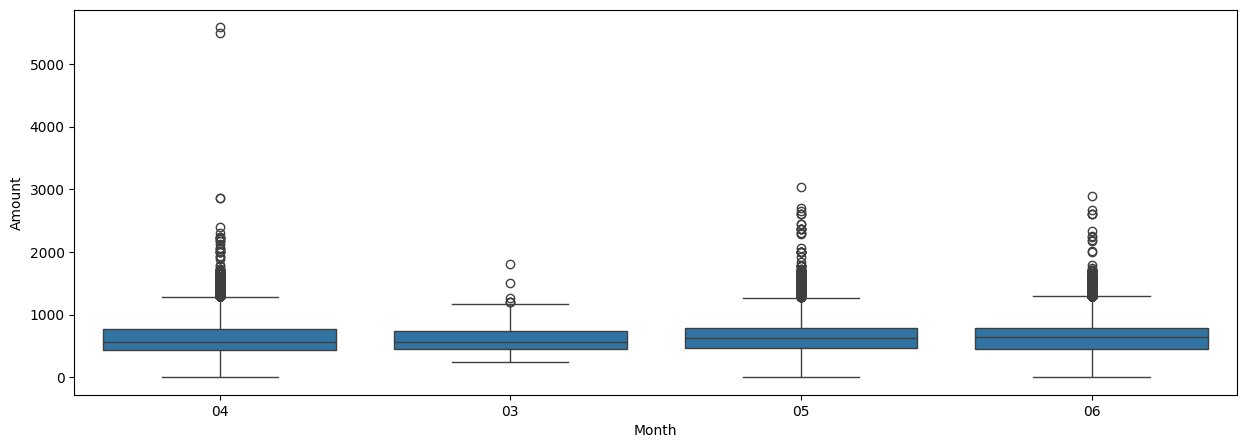

In [68]:
plt.figure(figsize=(15,5))
sns.boxplot(x='Month'
            , y = 'Amount'
            , data= df_amazon_sales_completed)
plt.show()

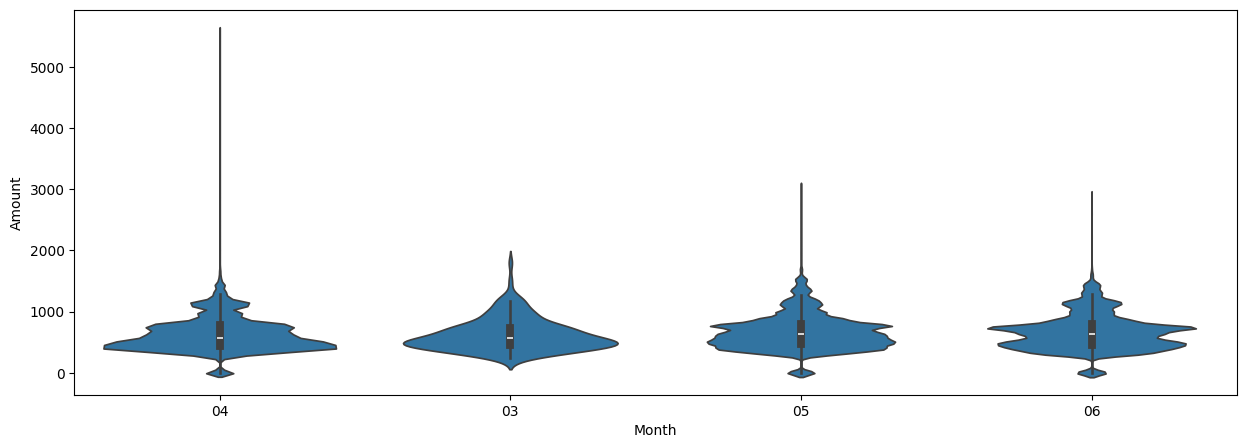

In [91]:
plt.figure(figsize=(15,5))
sns.violinplot(x='Month'
            , y = 'Amount'
            , data= df_amazon_sales_completed)
plt.show()

<b>Plotly visualizations for the above two data ( would be rendered in browser )

In [69]:
fig = pex.violin(data_frame= df_amazon_sales_completed, 
                   x= "Month" ,
                   y= "Amount")
fig.show(renderer="browser")

In [ ]:
fig = pex.box(data_frame= df_amazon_sales_completed, 
                   x= "Month" ,
                   y= "Amount")
fig.show(renderer="browser")

<b>
Category Line Plot
</b>

In [93]:
df_category_sales = df_amazon_sales_completed.groupby(["Month", "Category"]).agg(
    monthly_revenue = ("Amount", "sum"), 
    no_orders = ("Order ID", "nunique")
)

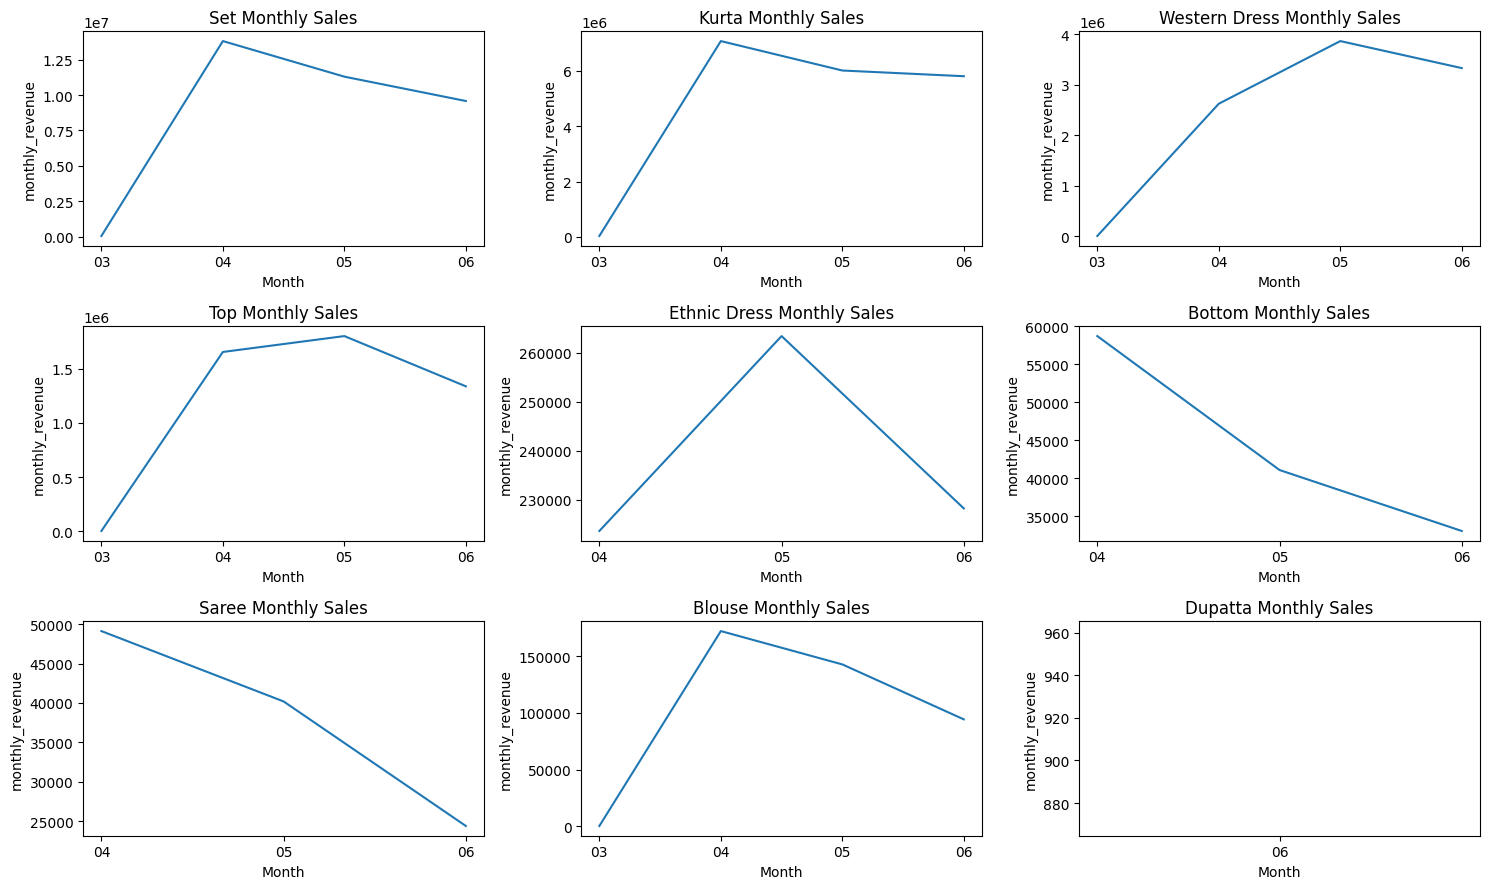

In [95]:
df_set_monthly_sales =   df_category_sales.xs("Set", level="Category")
df_kurta_monthly_sales = df_category_sales.xs("kurta", level="Category")
df_wes_monthly_sales =   df_category_sales.xs("Western Dress", level="Category")
df_top_monthly_sales =   df_category_sales.xs("Top", level="Category")
df_eth_monthly_sales =   df_category_sales.xs("Ethnic Dress", level="Category")
df_bot_monthly_sales =   df_category_sales.xs("Bottom", level="Category")
df_sar_monthly_sales =   df_category_sales.xs("Saree", level="Category")
df_blo_monthly_sales =   df_category_sales.xs("Blouse", level="Category")
df_dup_monthly_sales =   df_category_sales.xs("Dupatta", level="Category")

plt.figure(figsize=(15,9))
plt.subplot(3,3,1)
sns.lineplot(data=df_set_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Set Monthly Sales")

plt.subplot(3,3,2)
sns.lineplot(data=df_kurta_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Kurta Monthly Sales")

plt.subplot(3,3,3)
sns.lineplot(data=df_wes_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Western Dress Monthly Sales")

plt.subplot(3,3,4)
sns.lineplot(data=df_top_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Top Monthly Sales")

plt.subplot(3,3,5)
sns.lineplot(data=df_eth_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Ethnic Dress Monthly Sales")

plt.subplot(3,3,6)
sns.lineplot(data=df_bot_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Bottom Monthly Sales")

plt.subplot(3,3,7)
sns.lineplot(data=df_sar_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Saree Monthly Sales")

plt.subplot(3,3,8)
sns.lineplot(data=df_blo_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Blouse Monthly Sales")

plt.subplot(3,3,9)
sns.lineplot(data=df_dup_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Dupatta Monthly Sales")


plt.tight_layout()
plt.show()